<a href="https://colab.research.google.com/github/Sunidhi-Gautam/FL_Implementation/blob/main/Client_side_KD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sunidhigautam26","key":"df9c2dd0e0f5995bb0a2fd692c71ec16"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# ================== IMPORTS ==================
import os
import random
import shutil
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V2_Weights
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import json
import pandas as pd

# ================== DEVICE ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# ================== DRIVE ROOT ==================
DRIVE_ROOT = "/content/drive/MyDrive/clients_datasets"
os.makedirs(DRIVE_ROOT, exist_ok=True)

In [6]:
# ================== TRANSFORMS ==================
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# ================== DATASET DISTRIBUTION ==================
def view_distribution(base_dir, title):
    print(f"\n===== {title} =====\n")
    total_images = 0
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(base_dir, split)
        if not os.path.exists(split_dir):
            print(f"{split.upper()} SET: NOT FOUND\n")
            continue

        print(f"{split.upper()} SET:")
        split_total = 0
        classes = sorted([
            d for d in os.listdir(split_dir)
            if os.path.isdir(os.path.join(split_dir, d))
        ])
        for cls in classes:
            count = len(glob(os.path.join(split_dir, cls, "*")))
            print(f"{cls:<40} {count}")
            split_total += count
            total_images += count
        print(f"Total images in {split}: {split_total}\n")
    print(f"TOTAL IMAGES OVERALL: {total_images}")

**Client 1 Dataset Download**

In [8]:
CLIENT1_DIR = f"{DRIVE_ROOT}/client_1"

if not os.path.exists(CLIENT1_DIR):
    print("Downloading Client 1 dataset...")

    !kaggle datasets download -d musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd -p /content/client1_raw_kd
    !unzip -q /content/client1_raw_kd/*.zip -d /content/client1_raw_kd

    RAW_DIR = "/content/client1_raw_kd/Bangladeshi_Crops_Disease_Dataset"

    # VIEW ORIGINAL DATASET
    view_distribution(RAW_DIR, "CLIENT 1 – ORIGINAL DATASET")

    splits = ["train", "val", "test"]

    for split in splits:
        os.makedirs(os.path.join(CLIENT1_DIR, split), exist_ok=True)
        split_dir = os.path.join(RAW_DIR, split)

        # EXPLICIT TOMATO FILTER
        tomato_classes = [
            d for d in os.listdir(split_dir)
            if "tomato" in d.lower()
        ]

        assert len(tomato_classes) > 0, "No tomato classes found!"

        for cls in tomato_classes:
            src = os.path.join(split_dir, cls)
            dst = os.path.join(CLIENT1_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)

            for img in glob(os.path.join(src, "*")):
                shutil.copy(img, dst)

    print("Client 1 tomato-only dataset saved to Drive")

    # VIEW FINAL DATASET
    view_distribution(CLIENT1_DIR, "CLIENT 1 – TOMATO-ONLY (FINAL)")

else:
    print("Client 1 dataset already exists in Drive")
    view_distribution(CLIENT1_DIR, "CLIENT 1 – FROM DRIVE")

Dataset URL: https://www.kaggle.com/datasets/musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd
License(s): CC-BY-SA-4.0
  0% 0.00/37.6M [00:00<?, ?B/s]
100% 37.6M/37.6M [00:00<00:00, 1.62GB/s]

===== CLIENT 1 – ORIGINAL DATASET =====

TRAIN SET:
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 360
Corn_(maize)___Common_rust_              360
Corn_(maize)___Northern_Leaf_Blight      360
Corn_(maize)___healthy                   360
Potato___Early_blight                    360
Potato___Late_blight                     360
Potato___healthy                         360
Rice_bacterial_leaf_blight               360
Rice_brown_spot                          330
Rice_healthy                             330
Rice_leaf_blast                          330
Tomato___Bacterial_spot                  360
Tomato___Early_blight                    360
Tomato___Late_blight                     360
Tomato___healthy                         360
Wheat Brown rust                         360
Wheat Healthy        

In [9]:
CLIENT1_DIR = f"{DRIVE_ROOT}/client_1"

if not os.path.exists(CLIENT1_DIR):
    print("Downloading Client 1 dataset...")

    !kaggle datasets download -d musfiqurtuhin/bangladeshi-crops-disease-dataset-bcdd -p /content/client1_raw_kd
    !unzip -q /content/client1_raw_kd/*.zip -d /content/client1_raw_kd

    RAW_DIR = "/content/client1_raw_kd/Bangladeshi_Crops_Disease_Dataset"

    splits = ["train", "val", "test"]

    # VIEW ORIGINAL DATASET (FULL)
    view_distribution(RAW_DIR, "CLIENT 1 – ORIGINAL DATASET")

    for split in splits:
        split_src = os.path.join(RAW_DIR, split)
        split_dst = os.path.join(CLIENT1_DIR, split)
        os.makedirs(split_dst, exist_ok=True)

        # EXPLICIT TOMATO FILTER
        tomato_classes = [
            d for d in os.listdir(split_src)
            if os.path.isdir(os.path.join(split_src, d))
            and "tomato" in d.lower()
        ]

        assert len(tomato_classes) > 0, f"No tomato classes found in {split}!"

        for cls in tomato_classes:
            src = os.path.join(split_src, cls)
            dst = os.path.join(split_dst, cls)
            os.makedirs(dst, exist_ok=True)

            for img in glob(os.path.join(src, "*")):
                shutil.copy(img, dst)

    print("Client 1 tomato-only dataset saved to Drive")

    # VIEW FINAL DATASET (TOMATO ONLY)
    view_distribution(CLIENT1_DIR, "CLIENT 1 – TOMATO ONLY (FINAL)")

else:
    print("Client 1 dataset already exists in Drive")
    view_distribution(CLIENT1_DIR, "CLIENT 1 – FROM DRIVE")


Client 1 dataset already exists in Drive

===== CLIENT 1 – FROM DRIVE =====

TRAIN SET:
Tomato___Bacterial_spot                  360
Tomato___Early_blight                    360
Tomato___Late_blight                     360
Tomato___healthy                         360
Total images in train: 1440

VAL SET:
Tomato___Bacterial_spot                  72
Tomato___Early_blight                    72
Tomato___Late_blight                     72
Tomato___healthy                         72
Total images in val: 288

TEST SET:
Tomato___Bacterial_spot                  48
Tomato___Early_blight                    48
Tomato___Late_blight                     48
Tomato___healthy                         48
Total images in test: 192

TOTAL IMAGES OVERALL: 1920


**Client 2 Dataset Download**

In [10]:
CLIENT2_DIR = f"{DRIVE_ROOT}/client_2"

if not os.path.exists(CLIENT2_DIR):
    print("Downloading Client 2 dataset...")

    !kaggle datasets download -d ahmadzargar/tomato-leaf-disease-dataset-segmented -p /content/client2_raw_kd
    !unzip -q /content/client2_raw_kd/*.zip -d /content/client2_raw_kd

    SOURCE_DIR = "/content/client2_raw_kd/train"

    # VIEW ORIGINAL (UNSPLIT) DISTRIBUTION
    print("\n===== CLIENT 2 – ORIGINAL TRAIN FOLDER =====\n")
    for cls in sorted(os.listdir(SOURCE_DIR)):
        count = len(glob(os.path.join(SOURCE_DIR, cls, "*")))
        print(f"{cls:<40} {count}")

    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15
    random.seed(42)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(CLIENT2_DIR, split), exist_ok=True)

    # EXPLICIT TOMATO FILTER (SAFETY)
    classes = [
        d for d in os.listdir(SOURCE_DIR)
        if os.path.isdir(os.path.join(SOURCE_DIR, d))
        and "tomato" in d.lower()
    ]

    assert len(classes) > 0, "No tomato classes found in Client 2!"

    for cls in classes:
        imgs = glob(os.path.join(SOURCE_DIR, cls, "*"))
        random.shuffle(imgs)

        n = len(imgs)
        n_train = int(n * TRAIN_RATIO)
        n_val = int(n * VAL_RATIO)

        splits_map = {
            "train": imgs[:n_train],
            "val": imgs[n_train:n_train+n_val],
            "test": imgs[n_train+n_val:]
        }

        for split, split_imgs in splits_map.items():
            dst = os.path.join(CLIENT2_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)
            for img in split_imgs:
                shutil.copy(img, dst)

    print("Client 2 dataset split and saved to Drive")

    # VIEW FINAL DATASET
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FINAL SPLIT DATASET")

else:
    print("Client 2 dataset already exists in Drive")
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FROM DRIVE")

Dataset URL: https://www.kaggle.com/datasets/ahmadzargar/tomato-leaf-disease-dataset-segmented
License(s): CC0-1.0
 90% 145M/162M [00:00<00:00, 1.49GB/s]
100% 162M/162M [00:00<00:00, 1.39GB/s]

===== CLIENT 2 – ORIGINAL TRAIN FOLDER =====

Tomato___Bacterial_spot                  1000
Tomato___Early_blight                    1000
Tomato___Late_blight                     1000
Tomato___Leaf_Mold                       1000
Tomato___Septoria_leaf_spot              1000
Tomato___Spider_mites Two-spotted_spider_mite 1000
Tomato___Target_Spot                     1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus   1000
Tomato___Tomato_mosaic_virus             1000
Tomato___healthy                         1000
Client 2 dataset split and saved to Drive

===== CLIENT 2 – FINAL SPLIT DATASET =====

TRAIN SET:
Tomato___Bacterial_spot                  700
Tomato___Early_blight                    700
Tomato___Late_blight                     700
Tomato___Leaf_Mold                       700
Tomato___Septoria

In [11]:
CLIENT2_DIR = f"{DRIVE_ROOT}/client_2"

if not os.path.exists(CLIENT2_DIR):
    print("Splitting Client 2 dataset...")

    SOURCE_DIR = "/content/client2_raw_kd/train"   # original Kaggle structure

    TRAIN_RATIO = 0.7
    VAL_RATIO   = 0.15
    TEST_RATIO  = 0.15

    assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

    random.seed(42)

    splits = ["train", "val", "test"]
    for split in splits:
        os.makedirs(os.path.join(CLIENT2_DIR, split), exist_ok=True)

    classes = [
        d for d in os.listdir(SOURCE_DIR)
        if os.path.isdir(os.path.join(SOURCE_DIR, d))
    ]

    for cls in classes:
        imgs = glob(os.path.join(SOURCE_DIR, cls, "*"))
        random.shuffle(imgs)

        n = len(imgs)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        split_map = {
            "train": imgs[:n_train],
            "val":   imgs[n_train:n_train + n_val],
            "test":  imgs[n_train + n_val:]
        }

        for split, split_imgs in split_map.items():
            dst = os.path.join(CLIENT2_DIR, split, cls)
            os.makedirs(dst, exist_ok=True)

            for img in split_imgs:
                shutil.copy(img, dst)

    print("Client 2 dataset split and saved to Drive")

    # VIEW FINAL DISTRIBUTION
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FINAL SPLIT DATASET")

else:
    print("Client 2 dataset already exists in Drive")
    view_distribution(CLIENT2_DIR, "CLIENT 2 – FROM DRIVE")

Client 2 dataset already exists in Drive

===== CLIENT 2 – FROM DRIVE =====

TRAIN SET:
Tomato___Bacterial_spot                  700
Tomato___Early_blight                    700
Tomato___Late_blight                     700
Tomato___Leaf_Mold                       700
Tomato___Septoria_leaf_spot              700
Tomato___Spider_mites Two-spotted_spider_mite 700
Tomato___Target_Spot                     700
Tomato___Tomato_Yellow_Leaf_Curl_Virus   700
Tomato___Tomato_mosaic_virus             700
Tomato___healthy                         700
Total images in train: 7000

VAL SET:
Tomato___Bacterial_spot                  150
Tomato___Early_blight                    150
Tomato___Late_blight                     150
Tomato___Leaf_Mold                       150
Tomato___Septoria_leaf_spot              150
Tomato___Spider_mites Two-spotted_spider_mite 150
Tomato___Target_Spot                     150
Tomato___Tomato_Yellow_Leaf_Curl_Virus   150
Tomato___Tomato_mosaic_virus             150
Tomato___

In [12]:
import pandas as pd

def dataset_summary_compact(base_dir, client_name):
    splits = ["train", "val", "test"]
    summary_data = []

    for split in splits:
        split_dir = os.path.join(base_dir, split)
        if not os.path.exists(split_dir):
            continue

        classes = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
        num_classes = len(classes)
        total_images = sum(len(glob(os.path.join(split_dir, cls, "*"))) for cls in classes)

        summary_data.append({
            "Client": client_name,
            "Split": split,
            "# Classes": num_classes,
            "# Images": total_images
        })

    return pd.DataFrame(summary_data)

# Paths to datasets
CLIENT1_DIR = "/content/drive/MyDrive/clients_datasets/client_1"
CLIENT2_DIR = "/content/drive/MyDrive/clients_datasets/client_2"

# Generate compact summaries
df_client1 = dataset_summary_compact(CLIENT1_DIR, "Client 1")
df_client2 = dataset_summary_compact(CLIENT2_DIR, "Client 2")

# Combine
df_summary = pd.concat([df_client1, df_client2], ignore_index=True)
display(df_summary)

,Client,Split,# Classes,# Images
0,Client 1,train,4,1440
1,Client 1,val,4,288
2,Client 1,test,4,192
3,Client 2,train,10,7000
4,Client 2,val,10,1500
5,Client 2,test,10,1500


In [18]:
# ================== LOAD CLIENT DATA ==================
def load_client_data(client_dir, batch_size=32, use_sampler=True):
    train_ds = datasets.ImageFolder(f"{client_dir}/train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(f"{client_dir}/val",   transform=eval_tfms)
    test_ds  = datasets.ImageFolder(f"{client_dir}/test",  transform=eval_tfms)

    if use_sampler:
        # WeightedRandomSampler for class imbalance
        class_counts = [0]*len(train_ds.classes)
        for _, label in train_ds.samples:
            class_counts[label] += 1

        MAX_WEIGHT = 5.0
        sample_weights = [min(1.0/count if count>0 else 1.0, MAX_WEIGHT) for _, label in train_ds.samples]
        train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, num_workers=2, pin_memory=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds.classes

In [19]:
# ================== STUDENT MODEL ==================
class MobileNetStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load without pretrained weights for checkpoint compatibility
        self.model = models.mobilenet_v2(weights=None)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [20]:
# ================== LOAD CLIENT CHECKPOINT ==================
def load_client_model(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    new_state_dict = {}
    for k,v in state_dict.items():
        if k.startswith("model."):
            new_state_dict[k[len("model."):]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict, strict=False)  # strict=False avoids missing/unexpected keys
    model.to(device)
    model.eval()
    print(f"Client model loaded from {checkpoint_path} safely on {device}")
    return model


In [21]:
# ================== TRAINING FUNCTION ==================
def train_one_client(model, train_loader, val_loader, client_name, epochs=5, lr=1e-4):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        print(f"\n[{client_name}] Epoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        correct, total, running_loss = 0, 0, 0
        for imgs, labels in tqdm(train_loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- VALIDATION --------
        model.eval()
        correct, total, running_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [22]:
# ================== EVALUATION FUNCTION ==================
def evaluate_client(model, test_loader, classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nTest Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
# ================== LOAD CLIENT DATA ==================
def load_client_data(client_dir, batch_size=32, use_sampler=True):
    train_ds = datasets.ImageFolder(f"{client_dir}/train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(f"{client_dir}/val",   transform=eval_tfms)
    test_ds  = datasets.ImageFolder(f"{client_dir}/test",  transform=eval_tfms)

    if use_sampler:
        # WeightedRandomSampler for class imbalance
        class_counts = [0]*len(train_ds.classes)
        for _, label in train_ds.samples:
            class_counts[label] += 1

        MAX_WEIGHT = 5.0
        sample_weights = [min(1.0/count if count>0 else 1.0, MAX_WEIGHT) for _, label in train_ds.samples]
        train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, num_workers=2, pin_memory=True)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds.classes

In [47]:
# ================== STUDENT MODEL ==================
class MobileNetStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load without pretrained weights for checkpoint compatibility
        self.model = models.mobilenet_v2(weights=True)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [48]:
# ================== LOAD CLIENT CHECKPOINT ==================
def load_client_model(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    new_state_dict = {}
    for k,v in state_dict.items():
        if k.startswith("model."):
            new_state_dict[k[len("model."):]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict, strict=False)  # strict=False avoids missing/unexpected keys
    model.to(device)
    model.eval()
    print(f"Client model loaded from {checkpoint_path} safely on {device}")
    return model


In [49]:
# ================== TRAINING FUNCTION ==================
def train_one_client(model, train_loader, val_loader, client_name, epochs=5, lr=1e-4):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        print(f"\n[{client_name}] Epoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        correct, total, running_loss = 0, 0, 0
        for imgs, labels in tqdm(train_loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # -------- VALIDATION --------
        model.eval()
        correct, total, running_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [50]:
client_dir = "/content/drive/MyDrive/clients_datasets/client_1"
train_loader, val_loader, test_loader, client_classes = load_client_data(client_dir)

In [51]:
num_classes = len(client_classes)
client_model = MobileNetStudent(num_classes)
client_model = client_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]


In [52]:
history = train_one_client(
    model=client_model,
    train_loader=train_loader,
    val_loader=val_loader,
    client_name="Client 1",
    epochs=5,  # or more
    lr=1e-4
)


[Client 1] Epoch 1/5


Train Loss: 0.6112 | Train Acc: 0.7701 | Val Loss: 0.2228 | Val Acc: 0.9340

[Client 1] Epoch 2/5


Train Loss: 0.1493 | Train Acc: 0.9556 | Val Loss: 0.0998 | Val Acc: 0.9653

[Client 1] Epoch 3/5


Train Loss: 0.1071 | Train Acc: 0.9625 | Val Loss: 0.0871 | Val Acc: 0.9618

[Client 1] Epoch 4/5


Train Loss: 0.0588 | Train Acc: 0.9833 | Val Loss: 0.0761 | Val Acc: 0.9757

[Client 1] Epoch 5/5


Train Loss: 0.0281 | Train Acc: 0.9951 | Val Loss: 0.0542 | Val Acc: 0.9826


In [53]:
SAVE_DIR = "/content/drive/MyDrive/clients_models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(client_model.state_dict(), f"{SAVE_DIR}/client1_mobilenet.pth")
torch.save(history, f"{SAVE_DIR}/client1_history.pt")


In [54]:
os.path.exists(f"{SAVE_DIR}/client1_mobilenet.pth")

True


Test Accuracy: 96.35%

Classification Report:
                         precision    recall  f1-score   support

Tomato___Bacterial_spot     0.9792    0.9792    0.9792        48
  Tomato___Early_blight     0.9556    0.8958    0.9247        48
   Tomato___Late_blight     0.9400    0.9792    0.9592        48
       Tomato___healthy     0.9796    1.0000    0.9897        48

               accuracy                         0.9635       192
              macro avg     0.9636    0.9635    0.9632       192
           weighted avg     0.9636    0.9635    0.9632       192



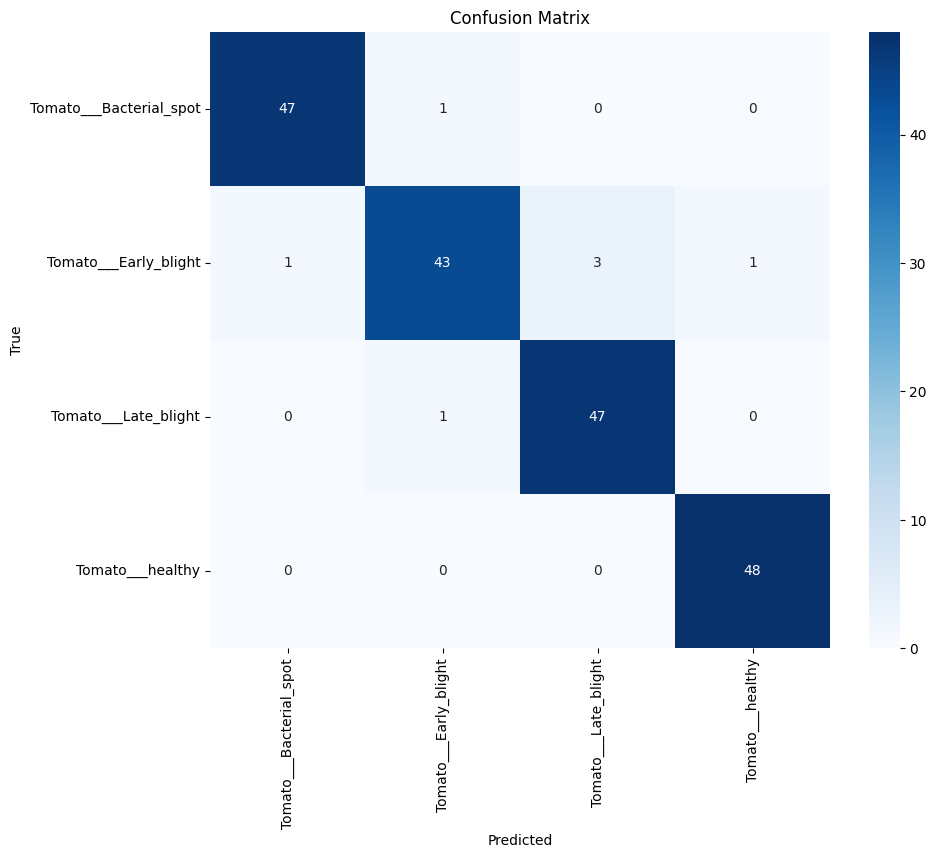

In [55]:
evaluate_client(client_model, test_loader, client_classes)

In [56]:
CLIENT_NAME = "Client 2"
CLIENT_DIR = "/content/drive/MyDrive/clients_datasets/client_2"
SAVE_DIR   = "/content/drive/MyDrive/clients_models"
os.makedirs(SAVE_DIR, exist_ok=True)

In [57]:
train_loader, val_loader, test_loader, client_classes = load_client_data(CLIENT_DIR, batch_size=32, use_sampler=True)
print(f"{CLIENT_NAME} Classes:", client_classes)

Client 2 Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [58]:
num_classes = len(client_classes)
client_model = MobileNetStudent(num_classes)
client_model = client_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [59]:
history = train_one_client(
    model=client_model,
    train_loader=train_loader,
    val_loader=val_loader,
    client_name=CLIENT_NAME,
    epochs=5,      # change as needed
    lr=1e-4
)


[Client 2] Epoch 1/5


Train Loss: 0.4610 | Train Acc: 0.8720 | Val Loss: 0.1250 | Val Acc: 0.9627

[Client 2] Epoch 2/5


Train Loss: 0.1234 | Train Acc: 0.9651 | Val Loss: 0.1138 | Val Acc: 0.9587

[Client 2] Epoch 3/5


Train Loss: 0.0703 | Train Acc: 0.9796 | Val Loss: 0.0657 | Val Acc: 0.9760

[Client 2] Epoch 4/5


Train Loss: 0.0511 | Train Acc: 0.9849 | Val Loss: 0.0615 | Val Acc: 0.9800

[Client 2] Epoch 5/5


Train Loss: 0.0432 | Train Acc: 0.9869 | Val Loss: 0.0644 | Val Acc: 0.9800


In [60]:
torch.save(client_model.state_dict(), f"{SAVE_DIR}/client2_mobilenet.pth")
torch.save(history, f"{SAVE_DIR}/client2_history.pt")
print(f"{CLIENT_NAME} model & history saved at {SAVE_DIR}")

Client 2 model & history saved at /content/drive/MyDrive/clients_models



Test Accuracy: 97.53%

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9803    0.9933    0.9868       150
                        Tomato___Early_blight     0.9524    0.9333    0.9428       150
                         Tomato___Late_blight     0.9477    0.9667    0.9571       150
                           Tomato___Leaf_Mold     0.9865    0.9733    0.9799       150
                  Tomato___Septoria_leaf_spot     0.9863    0.9600    0.9730       150
Tomato___Spider_mites Two-spotted_spider_mite     1.0000    0.9467    0.9726       150
                         Tomato___Target_Spot     0.9610    0.9867    0.9737       150
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9868    1.0000    0.9934       150
                 Tomato___Tomato_mosaic_virus     0.9868    1.0000    0.9934       150
                             Tomato___healthy     0.9675    0.9933    0.9803      

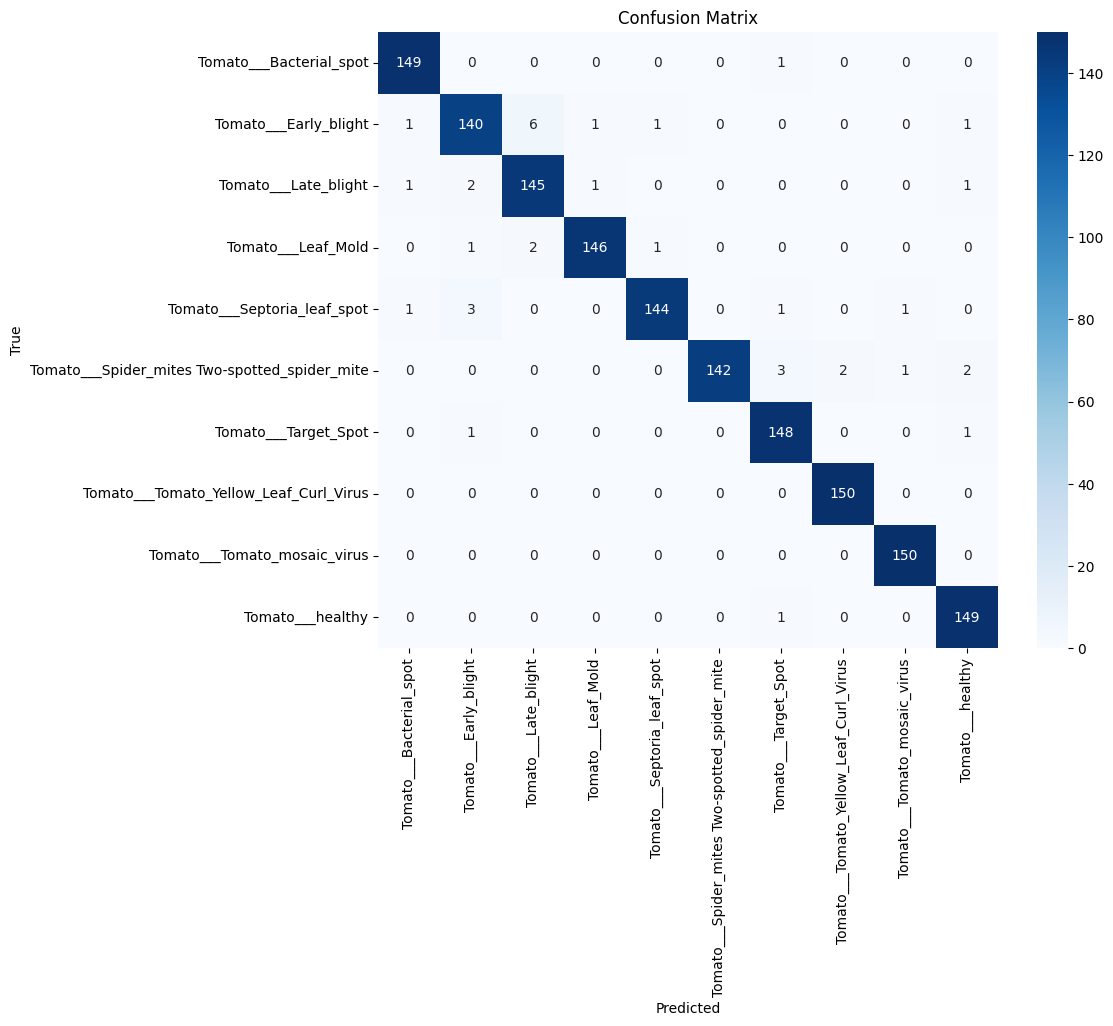

In [61]:
evaluate_client(client_model, test_loader, client_classes)

In [62]:
# ================== LOAD CLIENT MODEL ==================
def load_client_model(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    new_state_dict = {}
    for k,v in state_dict.items():
        if k.startswith("model."):
            new_state_dict[k[len("model."):]] = v
        else:
            new_state_dict[k] = v
    model.load_state_dict(new_state_dict, strict=False)
    model.to(device)
    model.eval()
    print(f"Client model loaded from {checkpoint_path} safely on {device}")
    return model

In [63]:
# ================== EXTRACT CLIENT PROTOTYPES ==================
def extract_client_prototypes(model, dataset_dir, batch_size=32):
    """
    Extract class-wise embeddings for KD
    """
    train_loader, _, _, classes = load_client_data(dataset_dir, batch_size=batch_size)
    model.eval()
    feature_extractor = nn.Sequential(*list(model.model.children())[:-1])  # everything except classifier
    feature_extractor.to(device)
    class_embeddings = {cls: [] for cls in classes}

    with torch.no_grad():
        for imgs, labels in tqdm(train_loader, desc="Extracting embeddings"):
            imgs, labels = imgs.to(device), labels.to(device)
            feats = feature_extractor(imgs)
            feats = feats.view(feats.size(0), -1)
            feats = F.normalize(feats, dim=1)  # normalize embedding
            for i, lbl in enumerate(labels):
                class_embeddings[classes[lbl]].append(feats[i].cpu().numpy())

    # Compute mean embedding per class
    prototypes = {}
    for cls in classes:
        prototypes[cls] = np.mean(np.stack(class_embeddings[cls]), axis=0)

    return prototypes, classes

In [64]:
# ================== NORMALIZE CLASS NAMES ==================
def normalize_class_names(prototypes_dicts):
    """
    prototypes_dicts: list of dicts from clients
    Returns: normalized dict mapping global class names -> list of embeddings
    """
    global_classes = set()
    for p in prototypes_dicts:
        global_classes.update(p.keys())
    global_classes = sorted(list(global_classes))

    normalized = {cls: [] for cls in global_classes}
    for p in prototypes_dicts:
        for cls in global_classes:
            if cls in p:
                normalized[cls].append(p[cls])
    return normalized, global_classes

In [65]:
# ================== AGGREGATE GLOBAL PROTOTYPES ==================
def aggregate_global_prototypes(normalized_dict):
    """
    For each class, average all client prototypes
    """
    global_prototypes = {}
    for cls, embeds in normalized_dict.items():
        global_prototypes[cls] = np.mean(np.stack(embeds), axis=0)
    return global_prototypes

In [66]:
# ================== LOAD CLIENT 1 DATA ==================
CLIENT1_DIR = "/content/drive/MyDrive/clients_datasets/client_1"

# Load data loaders and classes
train_loader_client1, val_loader_client1, test_loader_client1, client1_classes = load_client_data(CLIENT1_DIR, batch_size=32)

print("Client 1 Classes:", client1_classes)

Client 1 Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [67]:
# Initialize student model for Client 1
client1_model = MobileNetStudent(num_classes=len(client1_classes))

# Load trained checkpoint if exists
checkpoint_path = "/content/drive/MyDrive/clients_models/client1_mobilenet.pth"  # replace with your path
if os.path.exists(checkpoint_path):
    client1_model = load_client_model(client1_model, checkpoint_path)
else:
    print("Client 1 model not found. You need to train it first.")

Client model loaded from /content/drive/MyDrive/clients_models/client1_mobilenet.pth safely on cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Test Accuracy: 28.65%

Classification Report:
                         precision    recall  f1-score   support

Tomato___Bacterial_spot     0.2903    0.1875    0.2278        48
  Tomato___Early_blight     0.2000    0.0833    0.1176        48
   Tomato___Late_blight     0.3022    0.8750    0.4492        48
       Tomato___healthy     0.0000    0.0000    0.0000        48

               accuracy                         0.2865       192
              macro avg     0.1981    0.2865    0.1987       192
           weighted avg     0.1981    0.2865    0.1987       192



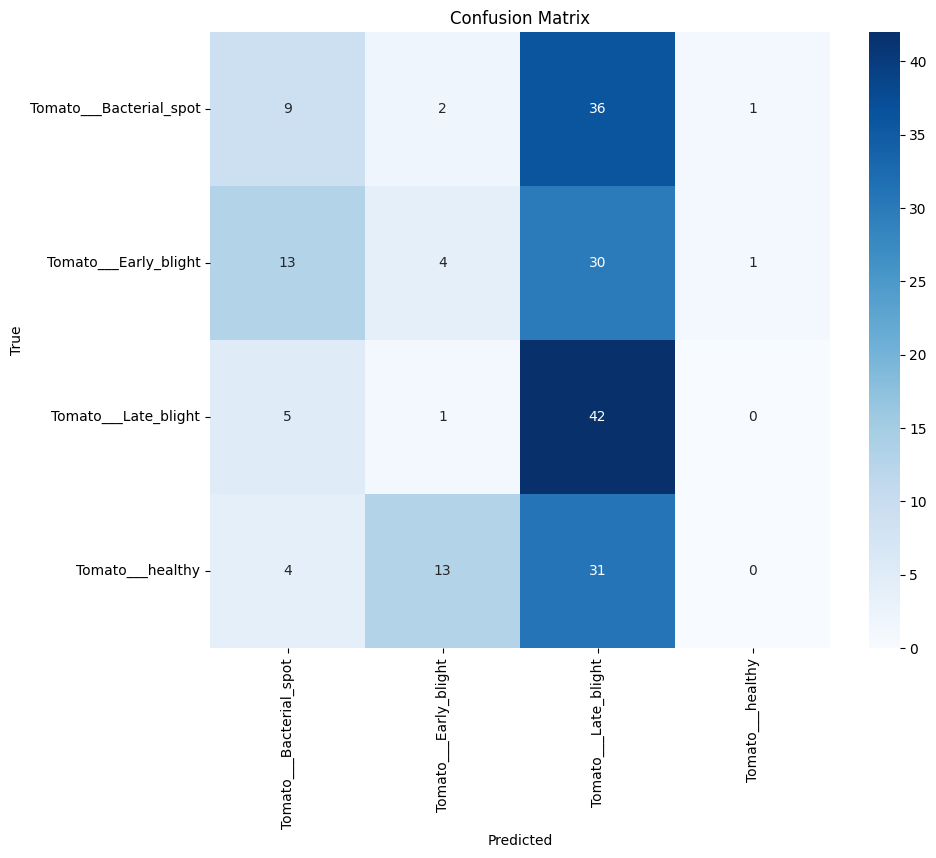

In [68]:
evaluate_client(client1_model, test_loader_client1, client1_classes)

In [73]:
import torch.nn.functional as F

# ---------------- CLIENT 1 ----------------
train_loader1, val_loader1, test_loader1, client1_classes = load_client_data(CLIENT1_DIR)

client1_model = MobileNetStudent(num_classes=len(client1_classes))
client1_model = load_client_model(client1_model, "/content/drive/MyDrive/clients_models/client1_mobilenet.pth")

# ---------------- CLIENT 2 ----------------
train_loader2, val_loader2, test_loader2, client2_classes = load_client_data(CLIENT2_DIR)

client2_model = MobileNetStudent(num_classes=len(client2_classes))
client2_model = load_client_model(client2_model, "/content/drive/MyDrive/clients_models/client2_mobilenet.pth")

# ---------------- EXTRACT & AGGREGATE ----------------
proto1, classes1 = extract_client_prototypes(client1_model, CLIENT1_DIR)
proto2, classes2 = extract_client_prototypes(client2_model, CLIENT2_DIR)

# Normalize class names
normalized_dict, global_classes = normalize_class_names([proto1, proto2])

# Aggregate global prototypes
global_prototypes = aggregate_global_prototypes(normalized_dict)

Client model loaded from /content/drive/MyDrive/clients_models/client1_mobilenet.pth safely on cuda
Client model loaded from /content/drive/MyDrive/clients_models/client2_mobilenet.pth safely on cuda


Extracting embeddings: 100%|██████████| 219/219 [00:42<00:00,  5.18it/s]


In [74]:
# Assuming your embeddings are in dictionaries like:
# proto1, proto2
# proto1 = {'tomato_early_blight': tensor(...), ...}

import torch

# Save Client 1 embeddings
torch.save(proto1, "/content/client1_prototypes.pt")
# Save Client 2 embeddings
torch.save(proto2, "/content/client2_prototypes.pt")

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [75]:
from google.colab import files

# Download Client 1
files.download("/content/client1_prototypes.pt")
# Download Client 2
files.download("/content/client2_prototypes.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

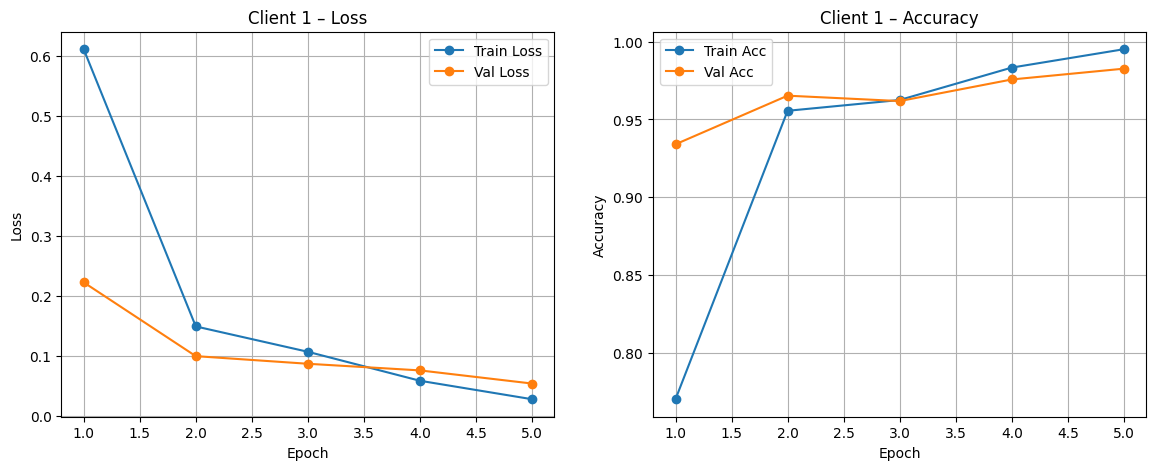

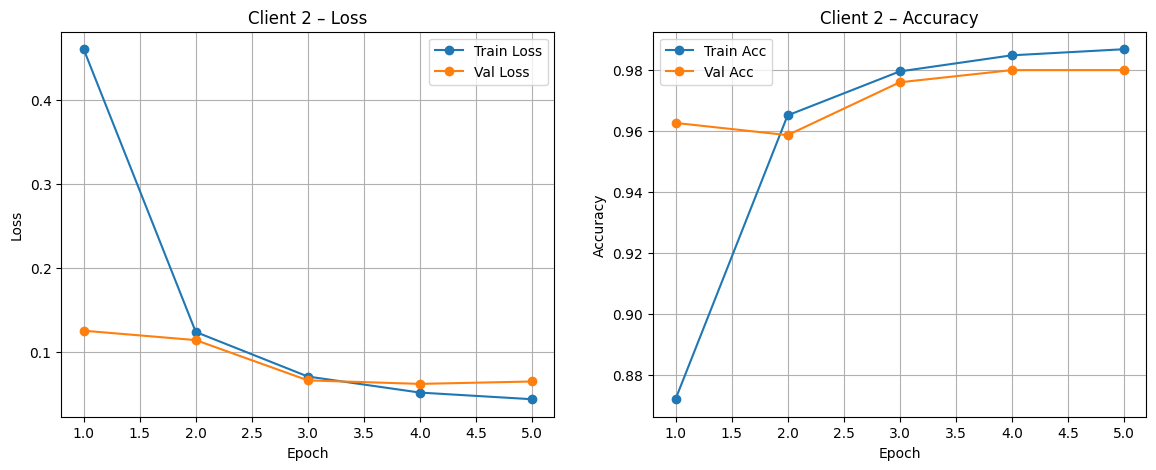

In [76]:
# ================= LOAD HISTORIES =================
# Example paths, replace with your saved histories
client1_history_path = "/content/drive/MyDrive/clients_models/client1_history.pt"
client2_history_path = "/content/drive/MyDrive/clients_models/client2_history.pt"

history1 = torch.load(client1_history_path)
history2 = torch.load(client2_history_path)

# ================= PLOT FUNCTION =================
def plot_client_curves(history, client_name):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14,5))

    # ----- Loss -----
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss')
    plt.title(f"{client_name} – Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # ----- Accuracy -----
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], marker='o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], marker='o', label='Val Acc')
    plt.title(f"{client_name} – Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.show()

# ================= PLOT FOR BOTH CLIENTS =================
plot_client_curves(history1, "Client 1")
plot_client_curves(history2, "Client 2")

In [79]:
teacher_soft_labels = torch.load(
    "/content/drive/MyDrive/teacher_soft_labels.pt",
    weights_only=False
)


In [80]:
teacher_soft_labels = torch.load(
    "/content/drive/MyDrive/teacher_soft_labels.pt",
    weights_only=False
)


In [81]:
import torch.nn.functional as F

def kd_loss(student_outputs, hard_labels, teacher_soft_label, temperature=2.0, alpha=0.5):
    """
    student_outputs: logits from student (batch_size x num_classes)
    hard_labels: ground truth labels (batch_size)
    teacher_soft_label: soft label vector from teacher (num_classes)
    temperature: temperature scaling
    alpha: weight between CE loss and KD loss
    """
    # ----------------- Cross Entropy Loss -----------------
    ce = F.cross_entropy(student_outputs, hard_labels)

    # ----------------- KL Divergence Loss -----------------
    # Student probabilities
    s_log_prob = F.log_softmax(student_outputs / temperature, dim=1)

    # Teacher probabilities (soft labels)
    t_prob = F.softmax(teacher_soft_label / temperature, dim=0)  # teacher_soft_label: (num_classes,)
    t_prob = t_prob.unsqueeze(0).expand_as(s_log_prob)  # expand to batch size

    kl = F.kl_div(s_log_prob, t_prob, reduction='batchmean') * (temperature ** 2)

    # ----------------- Combined Loss -----------------
    loss = alpha * ce + (1 - alpha) * kl
    return loss

In [87]:
train_loader1, val_loader1, test_loader1, client1_classes = load_client_data(CLIENT1_DIR)
train_loader2, val_loader2, test_loader2, client2_classes = load_client_data(CLIENT2_DIR)

In [89]:
def normalize_class_name(name):
    return name.lower().replace(" ", "_").replace("__", "_")

In [93]:
import re

def normalize_class_name(name):
    name = name.lower()
    name = name.replace("___", "_")
    name = name.replace("__", "_")
    name = name.replace(" ", "_")
    name = re.sub(r"[^a-z0-9_]", "", name)
    return name

In [94]:
teacher_soft_labels_raw = torch.load(
    "/content/drive/MyDrive/teacher_soft_labels.pt",
    weights_only=False
)

teacher_soft_labels = {
    normalize_class_name(k): v
    for k, v in teacher_soft_labels_raw.items()
}

In [95]:
client1_classes_normalized = [
    normalize_class_name(c) for c in client1_classes
]

In [99]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

CLIENT1_TRAIN_DIR = "/content/drive/MyDrive/clients_datasets/client_1/train"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset1 = ImageFolder(CLIENT1_TRAIN_DIR, transform=transform)
train_loader1 = DataLoader(train_dataset1, batch_size=32, shuffle=True)

client1_classes = train_dataset1.classes
print("Client-1 classes:", client1_classes)
print("Num classes:", len(client1_classes))


Client-1 classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']
Num classes: 4


In [100]:
labels_seen = set()
for _, labels in train_loader1:
    labels_seen.update(labels.tolist())

print("Max label index:", max(labels_seen))
print("Classes length:", len(client1_classes))

Max label index: 3
Classes length: 4


In [109]:
def normalize_class_name(name):
    name = name.lower()
    name = name.replace("___", "_")
    name = name.replace("__", "_")
    name = name.replace(" ", "_")
    name = name.replace("-", "_")
    return name

In [110]:
normalized_teacher_soft_labels = {
    normalize_class_name(k): v
    for k, v in teacher_soft_labels.items()
}

print("Teacher normalized classes:")
for k in normalized_teacher_soft_labels.keys():
    print(k)

Teacher normalized classes:
tomato_bacterial_spot
tomato_early_blight
tomato_late_blight
tomato_healthy
tomato_leaf_mold
tomato_septoria_leaf_spot
tomato_spider_mites_twospotted_spider_mite
tomato_target_spot
tomato_tomato_yellow_leaf_curl_virus
tomato_tomato_mosaic_virus


In [112]:
client1_class_map = {}

for cls in client1_classes:
    norm_cls = normalize_class_name(cls)

    if norm_cls in normalized_teacher_soft_labels:
        client1_class_map[cls] = norm_cls
    else:
        raise KeyError(f"[Client-1] Class not found in teacher: {cls}")

print("Client-1 class mapping:")
for k, v in client1_class_map.items():
    print(f"{k}  -->  {v}")

Client-1 class mapping:
Tomato___Bacterial_spot  -->  tomato_bacterial_spot
Tomato___Early_blight  -->  tomato_early_blight
Tomato___Late_blight  -->  tomato_late_blight
Tomato___healthy  -->  tomato_healthy


In [ ]:
import torch.nn.functional as F

def kd_loss(student_logits, teacher_logits, temperature):
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    return F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)

In [115]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

CLIENT2_TRAIN_DIR = "/content/drive/MyDrive/clients_datasets/client_2/train"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset2 = ImageFolder(CLIENT2_TRAIN_DIR, transform=transform)
train_loader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True)

client2_classes = train_dataset2.classes
print("Client-2 classes:", client2_classes)
print("Num classes:", len(client2_classes))

Client-2 classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Num classes: 10


In [118]:
labels_seen = set()
for _, labels in train_loader2:
    labels_seen.update(labels.tolist())

print("Max label index:", max(labels_seen))
print("Classes length:", len(client2_classes))

Max label index: 9
Classes length: 10


In [122]:
def normalize_class_name(name):
    name = name.lower()
    name = name.replace("___", "_")
    name = name.replace("__", "_")
    name = name.replace(" ", "_")
    name = name.replace("-", "_")

    name = name.replace("two_spotted", "twospotted")

    name = re.sub(r"_+", "_", name)
    name = name.strip("_")
    return name

In [123]:
normalized_teacher_soft_labels = {
    normalize_class_name(k): v
    for k, v in teacher_soft_labels.items()
}

print("Teacher normalized classes:")
for k in normalized_teacher_soft_labels.keys():
    print(k)

Teacher normalized classes:
tomato_bacterial_spot
tomato_early_blight
tomato_late_blight
tomato_healthy
tomato_leaf_mold
tomato_septoria_leaf_spot
tomato_spider_mites_twospotted_spider_mite
tomato_target_spot
tomato_tomato_yellow_leaf_curl_virus
tomato_tomato_mosaic_virus


In [125]:
client2_class_map = {}

for cls in client2_classes:
    norm_cls = normalize_class_name(cls)

    if norm_cls in normalized_teacher_soft_labels:
        client2_class_map[cls] = norm_cls
    else:
        raise KeyError(f"[Client-2] Class not found in teacher: {cls}")

print("Client-2 class mapping:")
for k, v in client2_class_map.items():
    print(f"{k}  -->  {v}")

Client-2 class mapping:
Tomato___Bacterial_spot  -->  tomato_bacterial_spot
Tomato___Early_blight  -->  tomato_early_blight
Tomato___Late_blight  -->  tomato_late_blight
Tomato___Leaf_Mold  -->  tomato_leaf_mold
Tomato___Septoria_leaf_spot  -->  tomato_septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite  -->  tomato_spider_mites_twospotted_spider_mite
Tomato___Target_Spot  -->  tomato_target_spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus  -->  tomato_tomato_yellow_leaf_curl_virus
Tomato___Tomato_mosaic_virus  -->  tomato_tomato_mosaic_virus
Tomato___healthy  -->  tomato_healthy


In [126]:
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

optimizer = optim.Adam(client1_model.parameters(), lr=1e-4)

ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")


In [131]:
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

def train_client_with_kd(
    student_model,
    train_loader,
    val_loader,
    student_classes,
    class_map,                 # client → teacher class mapping
    teacher_prototypes,        # {class_name: embedding}
    client_name="Client-1",
    epochs=5,
    alpha=0.7,
    lr=1e-4
):
    optimizer = optim.Adam(student_model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    student_model.to(device)

    for epoch in range(epochs):
        student_model.train()
        running_loss = 0.0

        print(f"\n[{client_name}] Epoch {epoch+1}/{epochs}")

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward with embeddings
            logits, student_emb = student_model(imgs, return_features=True)

            #  CE loss
            loss_ce = ce_loss(logits, labels)

            # Build teacher prototype batch
            batch_teacher = []
            for l in labels:
                cls_name = student_classes[l.item()]
                teacher_key = class_map[cls_name]
                batch_teacher.append(teacher_prototypes[teacher_key])

            batch_teacher = torch.stack(batch_teacher).to(device)

            # Prototype KD loss
            loss_kd = mse_loss(student_emb, batch_teacher)

            #  Total loss
            loss = (1 - alpha) * loss_ce + alpha * loss_kd
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        # Validation
        student_model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = student_model(imgs)

                loss = ce_loss(logits, labels)
                val_loss += loss.item()

                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [129]:
normalized_teacher_soft_labels = {
    cls: torch.tensor(vec, dtype=torch.float32).to(device)
    for cls, vec in normalized_teacher_soft_labels.items()
}

In [136]:
from torchvision.models import mobilenet_v2

class MobileNetStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = mobilenet_v2(weights="IMAGENET1K_V1")
        self.backbone.classifier = nn.Identity()

        self.embedding_dim = 1280   # MobileNetV2 feature size
        self.classifier = nn.Linear(self.embedding_dim, num_classes)

    def forward(self, x, return_features=False):
        features = self.backbone(x)          # [B, 1280]
        logits = self.classifier(features)   # [B, C]

        if return_features:
            return logits, features
        return logits

In [137]:
client1_model = MobileNetStudent(num_classes=len(client1_classes))

In [138]:
kd_history_client1 = train_client_with_kd(
    student_model=client1_model,
    train_loader=train_loader1,
    val_loader=val_loader1,
    student_classes=client1_classes,
    class_map=client1_class_map,
    teacher_prototypes=normalized_teacher_soft_labels,
    client_name="Client-1",
    epochs=5,
    alpha=0.7
)



[Client-1] Epoch 1/5


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([32, 62720])) that is different to the input size (torch.Size([32, 1280])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (1280) must match the size of tensor b (62720) at non-singleton dimension 1